Uppgift: Rena data. Bygg regressionsmodell och analysera prestanda. Vi ska säga om modellen är statistiskt signifikant.
Runt 10 variabler i ett dataset räcker att presentera, som en data-story.
10-15 minuters presentation då det är mer data att jobba mot.

Idé: Ta ett dataset för AirBnb Stockholm, rena data och bytt regressionsmodell, förslagsvis kan vi prediktera pris per natt.
Dataset: AirBnb (https://insideairbnb.com/)
listings.csv	Summary information and metrics for listings in Stockholm (good for visualisations).

In [176]:
import pandas as pd

# Bekanta oss med datasetet!

df = pd.read_csv('data/airbnb_listings_stockholm_detailed.csv')

print("df.shape")
print(df.shape)

print("5 första posterna (df.head()):")
print(df.head())

print("Statistik på alla numeriska kolumneriska kolumner (df.describe):")
print(df.describe())          # statistik på alla numeriska kolumner

print("Hur många observationer per område (df['neighbourhood'])")
print(df['neighbourhood_cleansed'].value_counts())  # hur många observationer i varje område

print("df.info()")
print(df.info())

df.shape
(4955, 79)
5 första posterna (df.head()):
       id                          listing_url       scrape_id last_scraped  \
0  164448  https://www.airbnb.com/rooms/164448  20250929042406   2025-09-29   
1  220851  https://www.airbnb.com/rooms/220851  20250929042406   2025-09-29   
2  238411  https://www.airbnb.com/rooms/238411  20250929042406   2025-09-29   
3  242188  https://www.airbnb.com/rooms/242188  20250929042406   2025-09-29   
4  273906  https://www.airbnb.com/rooms/273906  20250929042406   2025-09-29   

        source                                         name  \
0  city scrape  Double room in central Stockholm with Wi-Fi   
1  city scrape                      One room in appartement   
2  city scrape          Cozy apartment in central Stockholm   
3  city scrape  Single room in central Stockholm with Wi-Fi   
4  city scrape               Penthouse in central Stockholm   

                                         description  \
0  I am renting out a nice double room 

Rena lite data

In [177]:
# Städa och ändra price från str till int

cleandf = df.copy()
cleandf['price'] = cleandf['price'].str.replace('$','')
cleandf['price'] = cleandf['price'].str.replace(',','')
cleandf['price'] = cleandf['price'].astype(float)




In [178]:
# Kolla priser, något är extremt högt vilket skevar analysen 112218
print(cleandf['price'].describe())

print(cleandf['price'].max())



count      3190.000000
mean       1690.473041
std        3704.741906
min         120.000000
25%         753.000000
50%        1200.000000
75%        2000.000000
max      112218.000000
Name: price, dtype: float64
112218.0


In [31]:
# Exportera till Excel för enklare granskning
import openpyxl
df.to_excel('airbnb_stockholm.xlsx', index=False)

Gör en pairplot som ska vara kung för att analysera data visuellt.

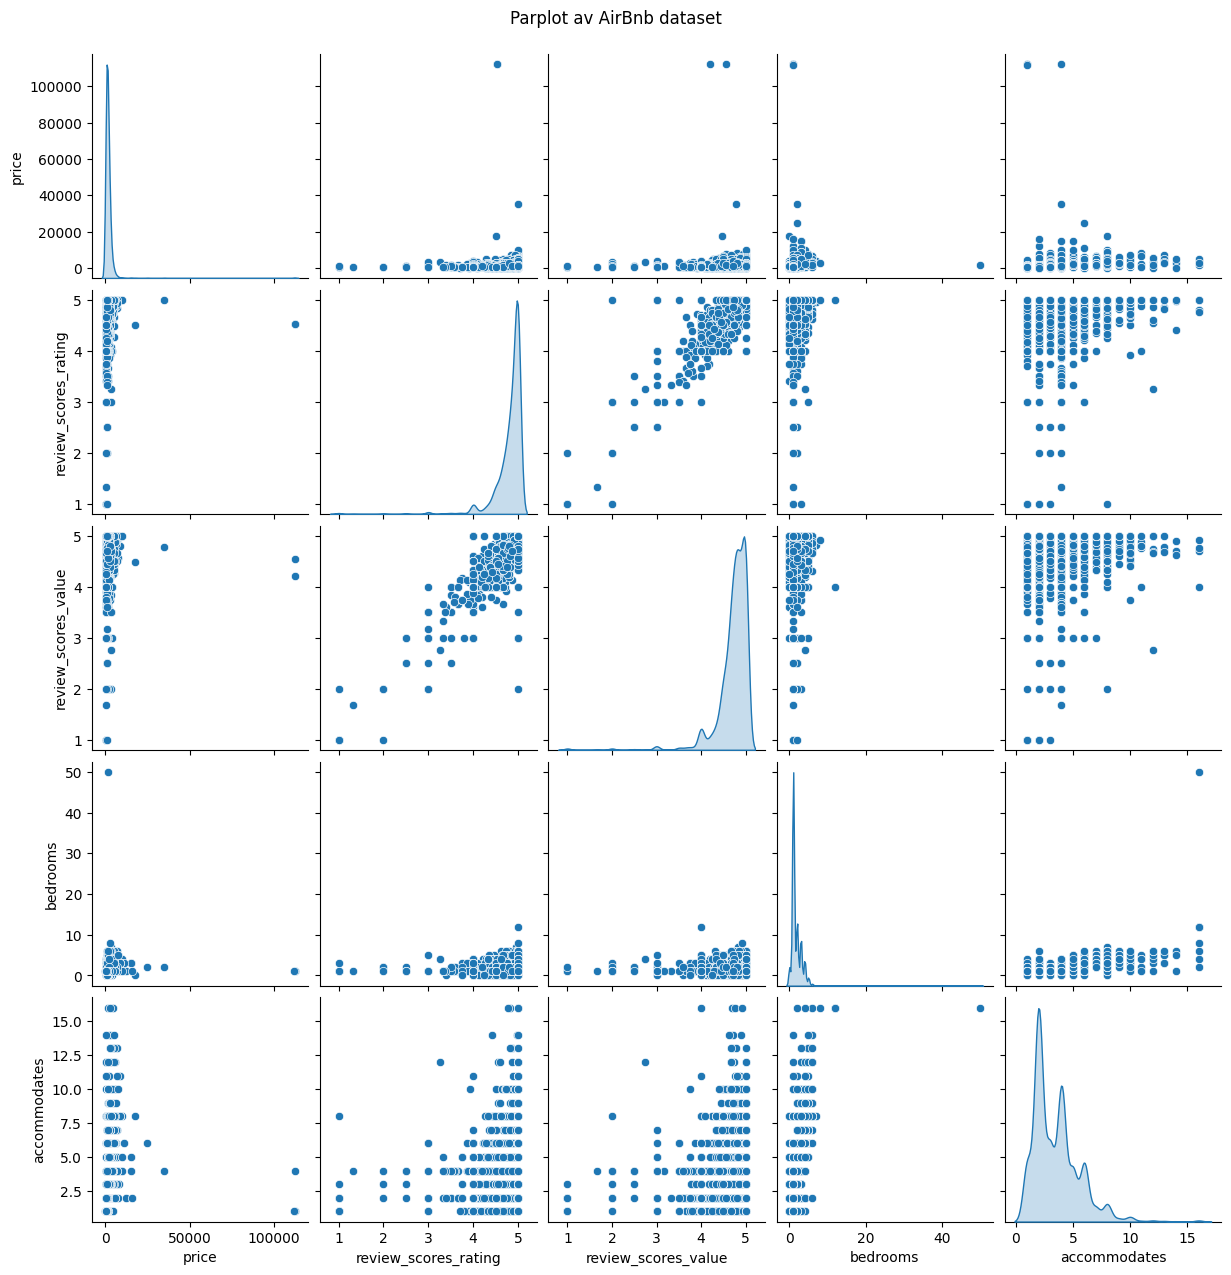

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['price','review_scores_rating','review_scores_value','room_type','bedrooms','accommodates']

pp = sns.pairplot(cleandf[cols], diag_kind='kde')
pp.figure.suptitle('Parplot av AirBnb dataset', y=1.02)

plt.show()

Datainmatningsfel i somliga fall gör att det finns extremvärden som gör att när $112,218.00 konverteras till float blir det 112218.
Vi väljer att göra percentilcapping och ha kvar värden inom 0.01 och 0.99 percentilen.

Vi upptäcker att det verkar vara datainmatningsfel på bedrooms också, någon ligger på 50 st. 50 rum motsvarar hela hotellets kapacitet.
name     room_type  property_type  bedrooms  bathrooms  \
3929  Älvsjö Stadshotell  Private room  Room in hotel      50.0       50.0   

      accommodates   price  
3929            16  1533.0  


Vi väljer att droppa alla poster som har över 20 bedrooms.


In [180]:
cleandf = cleandf[(cleandf['price'] >= cleandf['price'].quantile(0.01)) & 
              (cleandf['price'] <= cleandf['price'].quantile(0.99))] 

In [181]:
cleandf = cleandf[cleandf['bedrooms'] <= 20].copy()

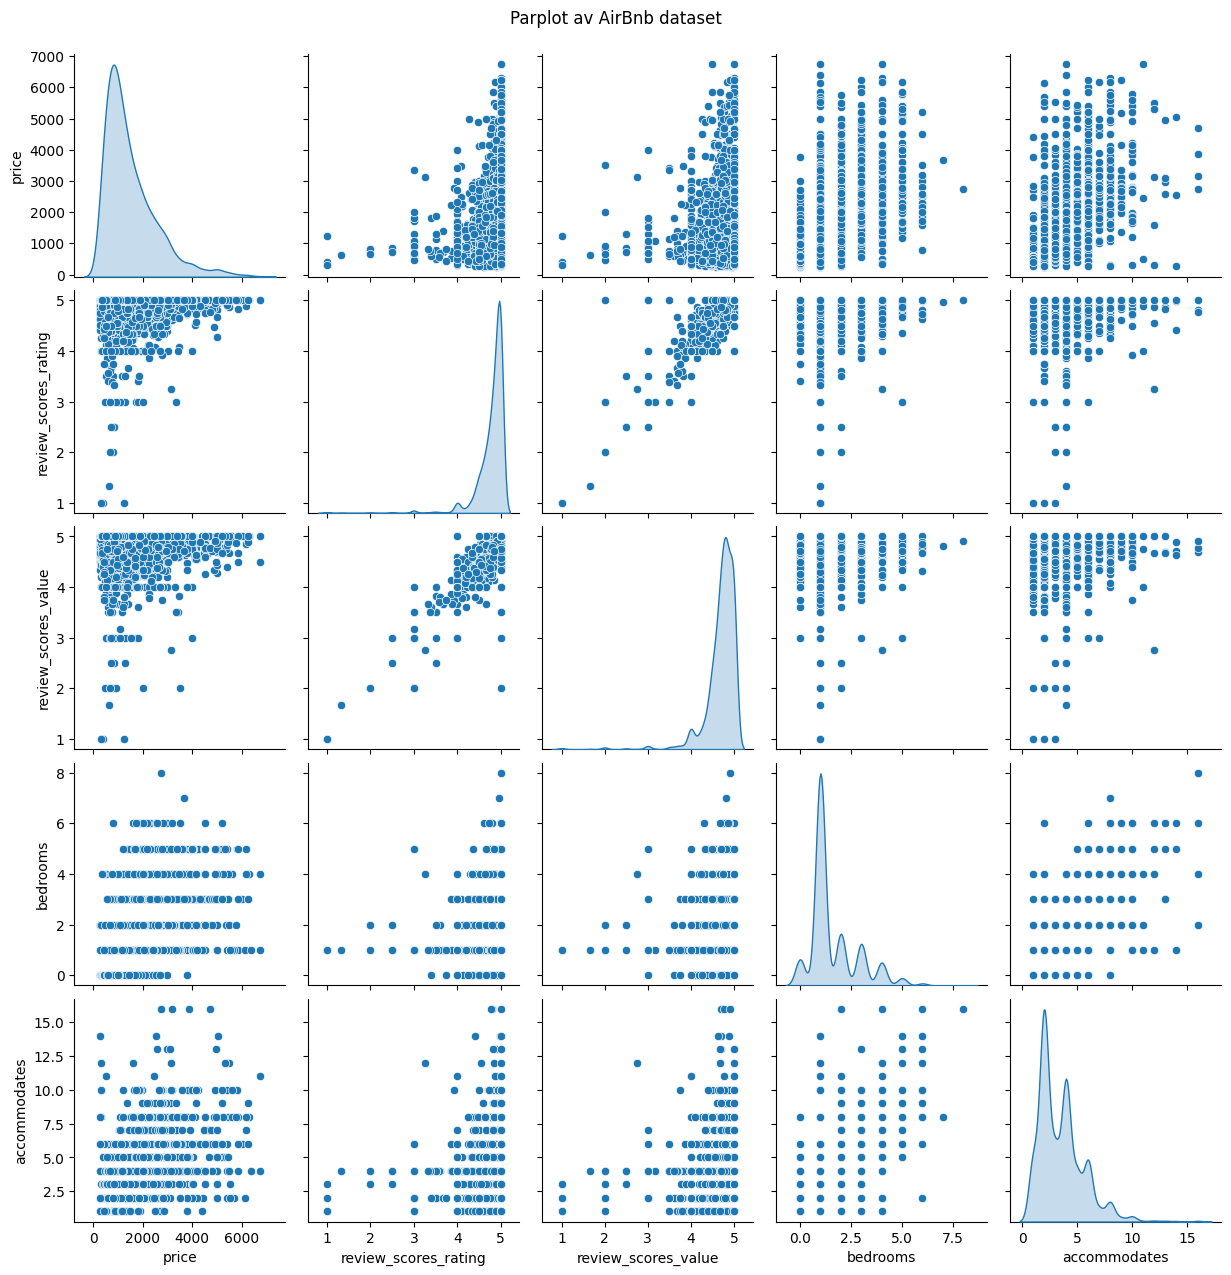

In [182]:
cols = ['price','review_scores_rating','review_scores_value','bedrooms','accommodates']

pp = sns.pairplot(cleandf[cols], diag_kind='kde')
pp.figure.suptitle('Parplot av AirBnb dataset', y=1.02)

plt.show()


In [158]:
# Har vi rimliga värden? Först se om vi har boenden  med över 20 rum. Sedan rumspriser över 6000
print(cleandf[cleandf['bedrooms'] > 20][['name', 'room_type', 'property_type', 'bedrooms', 'bathrooms', 'accommodates', 'price']])

print(cleandf[cleandf['price'] > 6000][['name', 'room_type', 'property_type', 'bedrooms', 'bathrooms', 'accommodates', 'price']])


Empty DataFrame
Columns: [name, room_type, property_type, bedrooms, bathrooms, accommodates, price]
Index: []
                                                   name        room_type  \
780          Upscale cityvilla with pool, gym and sauna  Entire home/apt   
1220                           Generator - Studio Suite     Private room   
2078                   Sekelskiftesfyra vid Mariatorget     Private room   
2374                                     Bryggan Ålsten  Entire home/apt   
2572                             Eget hus på Södermalm!  Entire home/apt   
2714  Unique colorful and spacious apartment in Old ...  Entire home/apt   
3126        Luxury Yacht near City Center for 1-11 pers  Entire home/apt   
3458                    Charmigt hus i Bromma Stockholm  Entire home/apt   
3462                    Supercentral sekelskiftesvåning  Entire home/apt   

               property_type  bedrooms  bathrooms  accommodates   price  
780             Entire villa       5.0        2.5      

Över 500/natt:  2794 poster
Över 1000/natt: 1856 poster
Över 2000/natt: 748 poster
Median: 1200


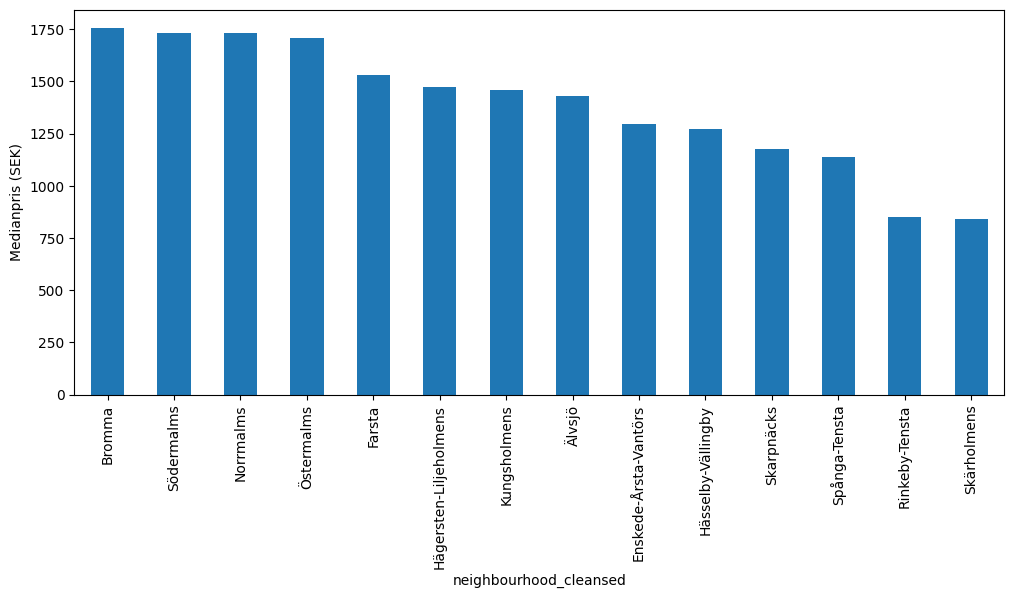

In [160]:
# Hur många poster ligger över rimlig USD-gräns?
print(f"Över 500/natt:  {(cleandf['price'] > 500).sum()} poster")
print(f"Över 1000/natt: {(cleandf['price'] > 1000).sum()} poster")
print(f"Över 2000/natt: {(cleandf['price'] > 2000).sum()} poster")

# Vad är medianpriset?
print(f"Median: {cleandf['price'].median():.0f}")



# Hur ser sambandet mellan område och rumspriser ut? Förutom att Farsta som inte är något finare område ligger bland toppen så verkar det relativt rimligt.
neighbourhood_avg = cleandf.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)
neighbourhood_avg.head(15).plot(kind='bar', figsize=(12, 5))
plt.ylabel('Medianpris (SEK)')
plt.show()

Kan vara rimligt att göra One-Hot encoding för att konvertera kategoriska värden som neighbourhood_cleansed (15 unika värden) för att kunna gå vidare med att analysera relationen mellan område och pris!
Linjär regression kräver numeriska inputs och kan inte hantera kategoriska variabler direkt, därav  gör vi One-Hot encoding (get_dummies), drop_first för att undvika dummy variabel-fälla.

In [202]:
cleandf = pd.get_dummies(cleandf, columns=['neighbourhood_cleansed'], drop_first=True)

cleandf = pd.get_dummies(cleandf, columns=['room_type'], drop_first=True, dtype=int)

In [200]:
cleandf.info()

<class 'pandas.DataFrame'>
Index: 3113 entries, 0 to 4954
Data columns (total 93 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   id                                             3113 non-null   int64  
 1   listing_url                                    3113 non-null   str    
 2   scrape_id                                      3113 non-null   int64  
 3   last_scraped                                   3113 non-null   str    
 4   source                                         3113 non-null   str    
 5   name                                           3113 non-null   str    
 6   description                                    3005 non-null   str    
 7   neighborhood_overview                          1128 non-null   str    
 8   picture_url                                    3113 non-null   str    
 9   host_id                                        3113 non-null   int64

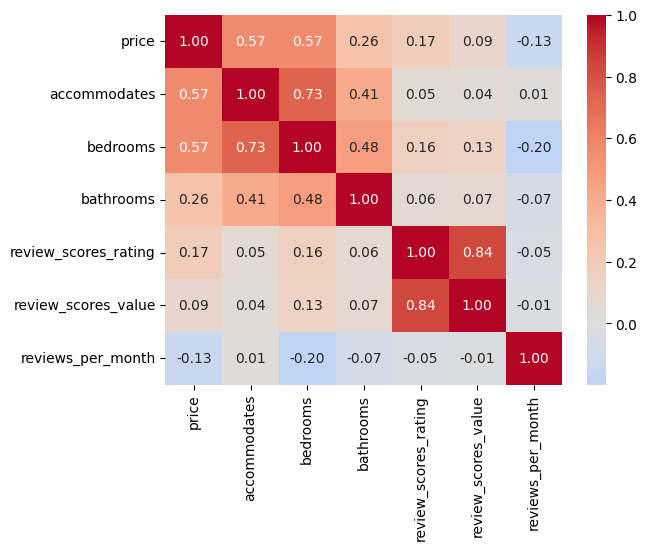

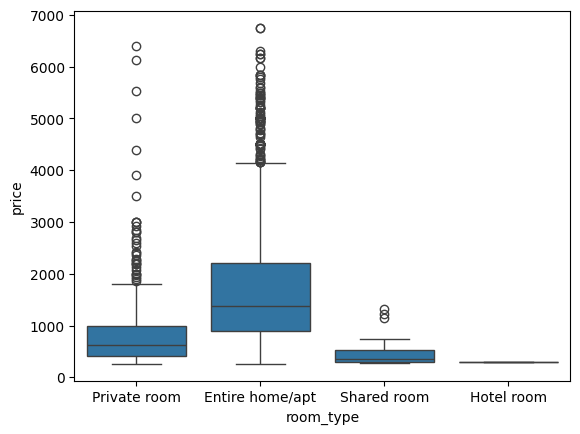

In [185]:
# Nu gör i en korrelations-heatmap för att visa samband med pris

cols = ['price', 'accommodates', 'bedrooms', 'bathrooms', 
        'review_scores_rating', 'review_scores_value', 'reviews_per_month']

sns.heatmap(cleandf[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

# Boxplot
sns.boxplot(data=cleandf, x='room_type', y='price')
plt.show()

In [186]:
# Lite mer datarening infor OLS-analysen. Ordinary least squares.

cleandf['price'].isnull().sum()

print(cleandf.isnull().sum())

id                                      0
listing_url                             0
scrape_id                               0
last_scraped                            0
source                                  0
                                       ..
neighbourhood_cleansed_Skärholmens      0
neighbourhood_cleansed_Spånga-Tensta    0
neighbourhood_cleansed_Södermalms       0
neighbourhood_cleansed_Älvsjö           0
neighbourhood_cleansed_Östermalms       0
Length: 91, dtype: int64


In [67]:
print(cleandf[cleandf['neighbourhood_cleansed_Farsta'] == True][['name', 'price', 'room_type', 'accommodates']].sort_values('price', ascending=False).head(10))
print(f"Antal listningar i Farsta: {(cleandf['neighbourhood_cleansed_Farsta'] ==  True).sum()}")

                                                   name   price  \
2939           Fantastisk villa med pool nära Stockholm  5195.0   
3579                           Elliotska villan sjönära  4770.0   
4110                            Badsemester i Stockholm  4000.0   
186    Modern och mysig villa med pool nära Stockholm C  3419.0   
2715           Elliotska villan next to lake Magelungen  3346.0   
1921  Villa vid badstrand i Stockholm, 15 min från City  3344.0   
4099         Nära bad och natur - 10 min från Södermalm  3300.0   
3660                    Mysigt hus med många sovplatser  3150.0   
815   Perfect place to stay in Stockholm - City & na...  3000.0   
4292                       Strandnära hus med sjöutsikt  3000.0   

            room_type  accommodates  
2939  Entire home/apt             9  
3579  Entire home/apt             7  
4110  Entire home/apt             6  
186   Entire home/apt             7  
2715  Entire home/apt             7  
1921  Entire home/apt             

In [ ]:
# Det förklarar saken! Farsta har stora villor med pool nära sjöar som drar upp medianen kraftigt.
#Det är inte ett dyrt innerstadsområde utan ett område med stora sommarvilla-typer med många sovplatser.

In [187]:
# Gör shapiro för att se om våra grupper av intresse är normalfördelade

from scipy.stats import shapiro

stat1, p1 = shapiro(cleandf['price'])

alpha = 0.05

if p1 < alpha:
    print(f"Grupp: Price. stat1: {stat1}. p-värde: {p1}. Vi kan förkasta nollhypotesen, inte normalfördelad")
else:
    print(f"Grupp: Price. stat1: {stat1}. p-värde: {p1}. Vi kan inte förkasta nollhypotesten, verkar normalfördelad")
    

# Gör pris logaritmiskt eftersom det inte är normalfördelat.
import numpy as np

cleandf['log_price'] = np.log1p(cleandf['price'])



Grupp: Price. stat1: 0.8614041344097955. p-värde: 3.4866202535568967e-46. Vi kan förkasta nollhypotesen, inte normalfördelad


In [194]:
X = sm.add_constant(cleandf['accommodates'])
y = cleandf['price']

# Kör modellen först
from scipy import stats
model = sm.OLS(y, X).fit()

# Testa residualerna
stat, p = stats.shapiro(model.resid)
print(f"Shapiro på residualer: p={p:.30f}")

Shapiro på residualer: p=0.000000000000000000000000000000


count    3113.000000
mean        7.105819
std         0.668978
min         5.556828
25%         6.637258
50%         7.090910
75%         7.596894
max         8.817446
Name: log_price, dtype: float64
0.003600169775482401


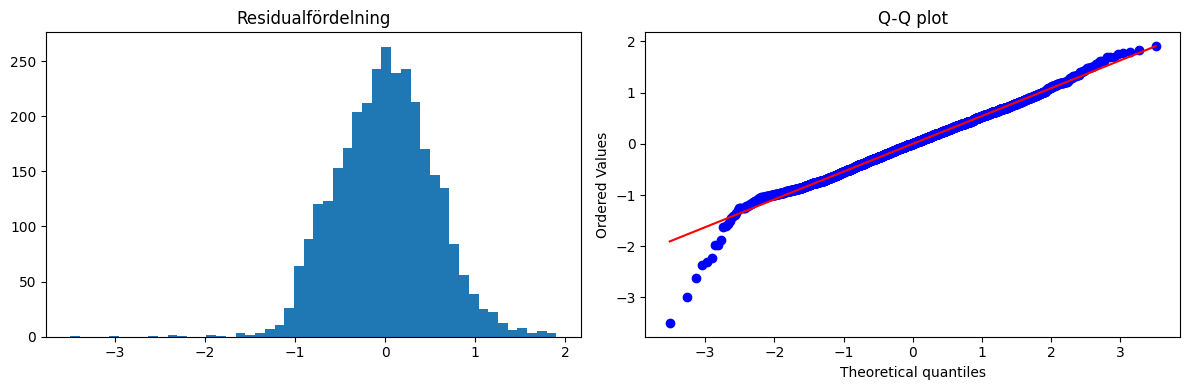

In [203]:
print(y.describe())
print(y.skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram av residualer
axes[0].hist(model.resid, bins=50)
axes[0].set_title('Residualfördelning')

# Q-Q plot
stats.probplot(model.resid, plot=axes[1])
axes[1].set_title('Q-Q plot')

plt.tight_layout()
plt.show()

OLS1. Pris - accomodates


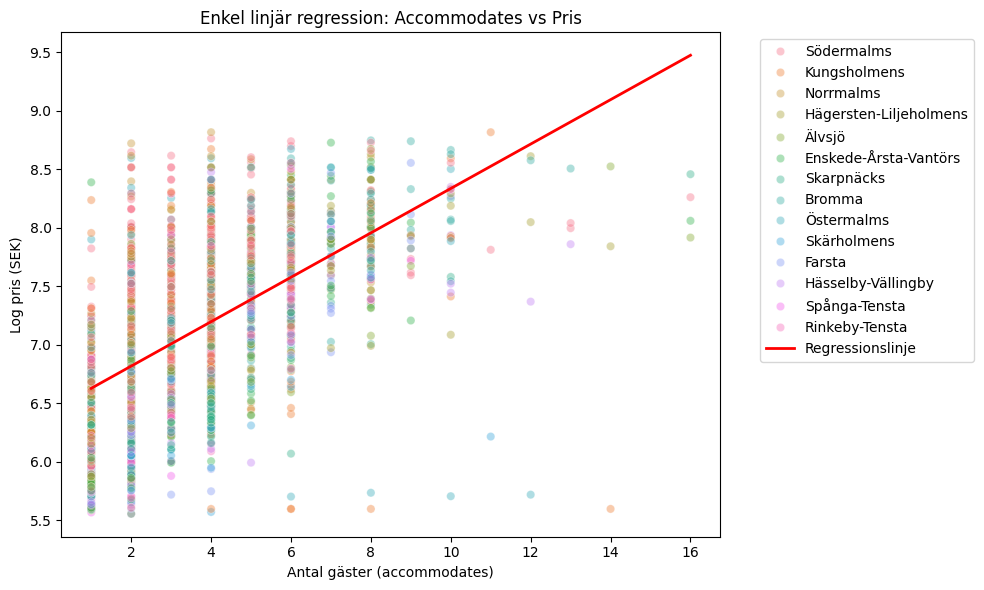

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     1577.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          2.03e-279
Time:                        21:56:01   Log-Likelihood:                -2526.8
No. Observations:                3113   AIC:                             5058.
Df Residuals:                    3111   BIC:                             5070.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.4395      0.019    331.703   

In [204]:
#Full regressionsmodell



import statsmodels.api as sm


# Enkel OLS: price ~ accommodates
print("OLS1. Pris - accomodates")
X = sm.add_constant(cleandf['accommodates'])
y = cleandf['log_price']
model = sm.OLS(y, X).fit()


cleandf['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].copy()
# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accommodates', y='log_price', 
                hue='neighbourhood_cleansed', 
                data=cleandf, alpha=0.4)

# Regressionslinje
x_range = np.linspace(cleandf['accommodates'].min(), cleandf['accommodates'].max(), 100)
y_pred = model.params['const'] + model.params['accommodates'] * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Regressionslinje')

plt.xlabel('Antal gäster (accommodates)')
plt.ylabel('Log pris (SEK)')
plt.title('Enkel linjär regression: Accommodates vs Pris')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(model.summary())




# Lägg till områden i ekvationen
# Multipel OLS med neighbourhood-dummies
print("OLS2. Pris - accomodates - neighbourhood")
# Konvertera kolumnerna i get_gummies fron boolean till int.
neighbourhood_dummies = [col for col in cleandf.columns if 'neighbourhood_cleansed_' in col]
cleandf[neighbourhood_dummies] = cleandf[neighbourhood_dummies].astype(int)

X = sm.add_constant(cleandf[['accommodates'] + neighbourhood_dummies])
y = cleandf['log_price']
model2 = sm.OLS(y, X).fit()
print(model2.summary())
print(f"\nR² ökning: {model.rsquared:.3f} → {model2.rsquared:.3f}")




# Lägg även till room type för att se om vi kan öka R-värdet ännu mer

# Gör den först till get_dummies
#cleandf = pd.get_dummies(cleandf, columns=['room_type'], drop_first=True)
print("OLS3. Pris - accomodates - neighbourhood - rumstyp")

# Exkludera originalkolumnen explicit
room_dummies = [col for col in cleandf.columns if 'room_type_' in col]

# Konvertera dom sedan till int
cleandf[room_dummies] = cleandf[room_dummies].astype(int)
X = sm.add_constant(cleandf[['accommodates'] + neighbourhood_dummies + room_dummies])
y = cleandf['log_price']
model3 = sm.OLS(y, X).fit()
print(model3.summary())
print(f"\nR² ökning: {model2.rsquared:.3f} → {model3.rsquared:.3f}")

In [97]:
print([col for col in cleandf.columns if 'room' in col.lower()])

['room_type', 'bathrooms', 'bathrooms_text', 'bedrooms', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']


In [201]:
print(room_dummies)

[]


In [109]:
# Det här är rent Claude
#%pip install scikit-learn
"""
Vi tränar modellen på 80% av Airbnb-listningarna
Sen frågar vi den att gissa priset på de 20% den aldrig sett
Om den gissar lika bra på båda — bra modell ✓
Om den är mycket bättre på träningsdata — den har "fuskläst" och fungerar inte i verkligheten ✗

MAE i SEK är sedan det enklaste måttet — om modellen i snitt gissar fel med 200 kr på ett pris på 1200 kr vet du direkt om det är acceptabelt eller inte.
"""
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Sätt ihop features
features = ['accommodates'] + neighbourhood_dummies + room_dummies
X = cleandf[features].astype(float)
y = cleandf['log_price']

# Train/test-split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Träna på träningsdata
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model_split = sm.OLS(y_train, X_train_sm).fit()

# Utvärdera på testdata
y_pred = model_split.predict(X_test_sm)

r2_train = r2_score(y_train, model_split.predict(X_train_sm))
r2_test = r2_score(y_test, y_pred)
mae_log = mean_absolute_error(y_test, y_pred)
mae_sek = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print(f"R² träning:  {r2_train:.3f}")
print(f"R² test:     {r2_test:.3f}")
print(f"MAE (log):   {mae_log:.3f}")
print(f"MAE (SEK):   {mae_sek:.0f} kr")

R² träning:  0.514
R² test:     0.508
MAE (log):   0.364
MAE (SEK):   565 kr


Kul lajban. Använd modellen för att tala om för oss om det är över/underpris

In [140]:




# Lägg till modellens prediktion och residual på varje listning
cleandf['predicted_log_price'] = model3.predict(sm.add_constant(cleandf[features]))
cleandf['predicted_price'] = np.expm1(cleandf['predicted_log_price'])
cleandf['residual'] = cleandf['price'] - cleandf['predicted_price']
cleandf['pct_diff'] = (cleandf['residual'] / cleandf['predicted_price']) * 100

# Visa de mest underprisade (bästa dealsen)
print("TOP 10 BÄSTA DEALS - billigare än modellen förväntar sig:")
print(cleandf[['name', 'neighbourhood_cleansed', 'room_type', 
               'accommodates', 'price', 'predicted_price', 'pct_diff','listing_url']]
      .sort_values('pct_diff')
      .head(10))

# Visa de mest överprisade
print("\nTOP 10 ÖVERPRISADE:")
print(cleandf[['name', 'neighbourhood_cleansed', 'room_type',
               'accommodates', 'price', 'predicted_price', 'pct_diff','listing_url']]
      .sort_values('pct_diff', ascending=False)
      .head(10))


TOP 10 BÄSTA DEALS - billigare än modellen förväntar sig:
                                                   name  \
4182                  A bed in a Mixed 14-bed dorm room   
3190                     Shared  6 Bed Female Dorm Room   
4590                             te sentirás en familia   
3193                     Shared  10 Bed Mixed Dorm Room   
3203                     Extra övernattnings rum i stan   
1084  Large Town House near Royal Castle, 400 years old   
4442                   Rymlig villa nära stad och natur   
4851          Mysig etta på Mariatorget! Uthyres 1-31/9   
3859   Peaceful & spacious Sthlm apt near city & nature   
2101                         Cozy flat by the waterside   

     neighbourhood_cleansed        room_type  accommodates   price  \
4182           Kungsholmens      Shared room            14   269.0   
3190             Östermalms      Shared room            12   304.0   
4590            Skärholmens     Private room            11   500.0   
3193        

In [162]:
# Priskalkylator

def analysera_pris(faktiskt_pris, accommodates, neighbourhood, room_type):
    # Bygg upp feature-vektorn
    row = {col: 0 for col in features}
    row['accommodates'] = accommodates
    
    # Sätt neighbourhood-dummy
    col_name = f'neighbourhood_cleansed_{neighbourhood}'
    if col_name in row:
        row[col_name] = 1
    
    # Sätt room_type-dummy
    room_col = f'room_type_{room_type}'
    if room_col in row:
        row[room_col] = 1
    
    X_new = pd.DataFrame([row])
    X_new.insert(0, 'const', 1.0)
    predicted_log = model3.predict(X_new)[0]
    predicted_log = model3.predict(X_new)[0]
    predicted_price = np.expm1(predicted_log)
    
    diff_pct = (faktiskt_pris - predicted_price) / predicted_price * 100
    
    if diff_pct < -20:
        omdome = "Riktigt bra deal!"
    elif diff_pct < 0:
        omdome = "Lite under förväntat pris"
    elif diff_pct < 20:
        omdome = "Ungefär rätt pris"
    else:
        omdome = "Överprisat"
    
    print(f"Faktiskt pris:    {faktiskt_pris:.0f} SEK")
    print(f"Förväntat pris:   {predicted_price:.0f} SEK")
    print(f"Skillnad:         {diff_pct:+.1f}%")
    print(f"Omdöme:           {omdome}")

# Exempel
analysera_pris(
    faktiskt_pris=1000,
    accommodates=1,
    neighbourhood='Rinkeby-Tensta',
    room_type='Entire home/apt'
)

Faktiskt pris:    1000 SEK
Förväntat pris:   599 SEK
Skillnad:         +66.9%
Omdöme:           Överprisat


id                     0
listing_url            0
scrape_id              0
last_scraped           0
source                 0
                      ..
predicted_log_price    0
predicted_price        0
residual               0
pct_diff               0
room_type              0
Length: 100, dtype: int64
